<a href="https://colab.research.google.com/github/rajivbandaru97/Credit-Risk-Analytics/blob/main/PD_Credit_ScoreCard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Package Installations

In [ ]:
pip install scorecardpy==0.1.9.7 scikit-learn==1.5.2 xgboost==2.1.3 shap pandas matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 86.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 351.5/351.5 MB 1.3 MB/s eta 0:00:00
  Created wheel for scorecardpy: filename=scorecardpy-0.1.9.7-py3-none-any.whl size=60724 sha256=265b7955fea2c15f78025347a6088ad010e49a1c7bea0c3c6591957f1abd1b89
  Stored in directory: /root/.cache/pip/wheels/d7/a8/fb/593dcef7717ee8a731e22872353b598d8d8bef4ee405a1c54a
Successfully built scorecardpy
  Attempting uninstall: xgboost
    Found existing installation: xgboost 3.4.1
    Uninstalling xgboost-3.4.1:
      Successfully uninstalled xgboost-3.4.1
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
ERROR: p

The packages are getting installed in order to generate scorecard. We are using scorecardpy for WOE binning and scorecard generation, scikit-learn for logistic regression, XG boost for challenger model comparison

# Loading the data

In this step we will be loading the data and analysing the same. SHAPE will give us the dimensions of the data in rows and columns, dtypes help us understand the datatypes, isnull() and sum() will be used to understand the null values present in the data. value_counts(normalize=True) helps us understand the good and bad in the data

In [ ]:
import scorecardpy as sc
import pandas as pd

data = pd.read_csv('/content/loan_data.csv')
print(data.shape)
print(data.dtypes)
print(data.isnull().sum())
print(data['loan_status'].value_counts(normalize=True))

(2000, 74)
id                    int64
member_id             int64
loan_amnt             int64
funded_amnt           int64
funded_amnt_inv       int64
                     ...   
all_util            float64
total_rev_hi_lim      int64
inq_fi                int64
total_cu_tl           int64
inq_last_12m          int64
Length: 74, dtype: object
id                  0
member_id           0
loan_amnt           0
funded_amnt         0
funded_amnt_inv     0
                   ..
all_util            0
total_rev_hi_lim    0
inq_fi              0
total_cu_tl         0
inq_last_12m        0
Length: 74, dtype: int64
loan_status
Current               0.2090
In Grace Period       0.2075
Late (31-120 days)    0.2075
Charged Off           0.1975
Fully Paid            0.1785
Name: proportion, dtype: float64


# Filter variables by predictive power (IV)

We will now use Information value to decide which variables to be kept.
sc.var_filter() automatically removes variables with IV below 0.02 (useless predictive power), missing rates above 95%, or identical-value rates above 95%. It returns a cleaned DataFrame with only the surviving features.

sc.iv() calculates the raw Information Value for every variable. This gives you visibility into exactly how predictive each feature is.

In order to carry out the operation, we first need to map the data in "loan_status" into binary values, as they are in 5 unique text values. It will else become difficult for the scorecardpy to process. After the mapping should we proceed ahead with the Information value steps

In [ ]:
import pandas as pd
import scorecardpy as sc

data = pd.read_csv('/content/loan_data.csv') # Reload data to ensure it's not empty

# 1. Clean the text data completely (removes hidden leading/trailing spaces)
data['loan_status'] = data['loan_status'].astype(str).str.strip()

# 2. Define the map explicitly
status_map = {
    'Fully Paid': 0,
    'Current': 0,
    'Charged Off': 1,
    'Late (31-120 days)': 1,
    'In Grace Period': 1
}

# 3. Map values and drop any row that could not be mapped (to avoid NaNs)
data['loan_status'] = data['loan_status'].str.strip().map(status_map)
#data = data.dropna(subset=['loan_status'])

# 4. Safely convert target to integer so scorecardpy reads it smoothly
data['loan_status'] = data['loan_status'].astype(int)

#5. Filter variables by IV
dt_f = sc.var_filter(data, y='loan_status')
print(f"Variable filtering complete! New shape: {dt_f.shape}")

#7. IV Values
iv = sc.iv(data, y='loan_status')
print(iv)


[INFO] filtering variables ...
Variable filtering on 2000 rows and 74 columns in 00:00:25 
44 variables are removed
Variable filtering complete! New shape: (2000, 30)
                     variable  info_value
39           earliest_cr_line    0.598777
20                 revol_util    0.482806
5                     il_util    0.461166
56                   zip_code    0.459589
40                   all_util    0.454757
..                        ...         ...
51           annual_inc_joint    0.000000
62                  dti_joint    0.000000
57         total_rec_late_fee    0.000000
59  verification_status_joint    0.000000
60                policy_code    0.000000

[73 rows x 2 columns]


# Training the data

We will now use the filtered data and based on the same will split it into training and testing. For scorecard development, split of 70% train and 30% test is followed.

sc.split_df() creates a stratified split, keeping the same ratio of good-to-bad borrowers in both sets.



ratio=0.7 puts 70% of the data in train and 30% in test.



seed=42 makes the split reproducible so you get consistent results every time.



Printing value_counts(normalize=True) for both sets confirms the stratification worked correctly

In [ ]:
# Train/test split
dt_list = sc.split_df(dt_f, y='loan_status', ratio=0.7, seed=42)
train = dt_list['train']
test = dt_list['test']
print(train['loan_status'].value_counts(normalize=True))
print(test['loan_status'].value_counts(normalize=True))

loan_status
1    0.612857
0    0.387143
Name: proportion, dtype: float64
loan_status
1    0.611667
0    0.388333
Name: proportion, dtype: float64


# Build WOE bins and transform features

Generating optimal WOE bins

In [ ]:
dt_f = sc.var_filter(data, y='loan_status')
dt_list = sc.split_df(dt_f, y='loan_status', ratio=0.7, seed=42)
train = dt_list['train']
test = dt_list['test']

[INFO] filtering variables ...
Variable filtering on 2000 rows and 74 columns in 00:00:25 
44 variables are removed


In [ ]:
# Generate WoE bins
bins = sc.woebin(dt_f, y='loan_status')
print(bins['sub_grade'])

/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is

[INFO] creating woe binning ...
>>> There are 5 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
issue_d, earliest_cr_line, last_credit_pull_d, last_pymnt_d, zip_code
>>> Continue the binning process?
1: yes 
2: no
Selection: 1


/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the stri

Binning on 2000 rows and 30 columns in 00:01:16
    variable                                              bin  count  \
0  sub_grade                      E2%,%E4%,%C3%,%C5%,%E1%,%D2    373   
1  sub_grade       C4%,%A5%,%E5%,%F3%,%D1%,%F5%,%D4%,%B3%,%G5    532   
2  sub_grade                 G1%,%B4%,%G3%,%B5%,%A1%,%D3%,%F1    380   
3  sub_grade  B2%,%F4%,%G4%,%G2%,%B1%,%A3%,%A4%,%F2%,%A2%,%E3    554   
4  sub_grade                                     C1%,%C2%,%D5    161   

   count_distr  good  bad   badprob       woe    bin_iv  total_iv  \
0       0.1865   186  187  0.501340 -0.452471  0.039522   0.08845   
1       0.2660   222  310  0.582707 -0.123938  0.004138   0.08845   
2       0.1900   143  237  0.623684  0.047382  0.000424   0.08845   
3       0.2770   183  371  0.669675  0.248883  0.016607   0.08845   
4       0.0805    41  120  0.745342  0.616087  0.027758   0.08845   

                                            breaks  is_special_values  
0                      E2%,%E4%,

/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:442: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  binning_1bst_brk = binning_1bst_brk.groupby(['variable', 'bstbin'], group_keys=False)\
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  .agg({'good':sum, 'bad':sum}).reset_index().assign(bin=lambda x: x['bstbin'])\
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:443: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be us

`sc.woebin()` automatically finds optimal bin boundaries for every variable in your filtered dataset. It calculates the WoE and Information Value (IV) for each bin.

The output is a dictionary where each key is a variable name and each value is a DataFrame showing bin boundaries, event counts, non-event counts, WoE values, and IV contribution per bin.

{'sub_grade': <Figure size 640x480 with 2 Axes>}

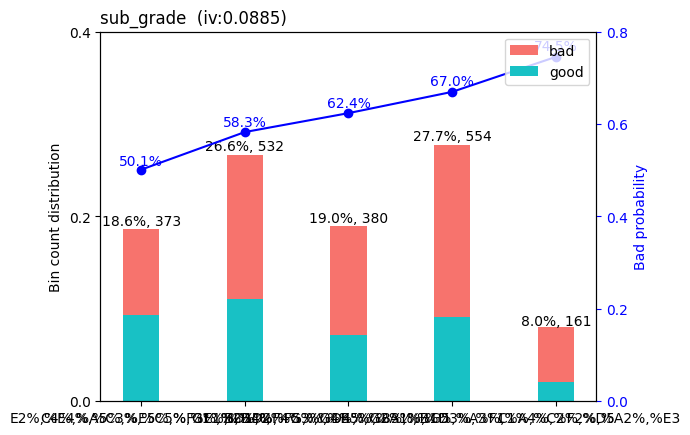

In [ ]:
# Plot WoE bins for sub_grade
sc.woebin_plot(bins['sub_grade'])

We will now transform train and test into WOE values. Doing so will eventually help get a uniform continuous values that logistic regression can consume

In [ ]:
# Transform train and test to WoE values
bins_adj = sc.woebin(dt_f, y='loan_status')
train_woe = sc.woebin_ply(train, bins_adj)
test_woe = sc.woebin_ply(test, bins_adj)
print(train_woe.head())
print(test_woe.head())

/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/usr/local/lib/python3.13/dist-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is

[INFO] creating woe binning ...
>>> There are 5 variables have too many unique non-numberic values, which might cause the binning process slow. Please double check the following variables: 
issue_d, earliest_cr_line, last_credit_pull_d, last_pymnt_d, zip_code
>>> Continue the binning process?
1: yes 
2: no
Selection: 1


/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  init_bin = init_bin.groupby('brkp', group_keys=False).agg({
/usr/local/lib/python3.13/dist-packages/scorecardpy/woebin.py:361: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the stri

Binning on 2000 rows and 30 columns in 00:01:16
[INFO] converting into woe values ...
[INFO] converting into woe values ...
   loan_status  earliest_cr_line_woe  all_util_woe  sub_grade_woe  \
0            1              4.546113     -0.162604      -0.123938   
1            0             -0.801890      0.187812      -0.123938   
3            1              0.922562      0.187812       0.047382   
4            1              0.922562     -0.106072      -0.452471   
5            1             -0.801890      0.186043       0.616087   

   il_util_woe  tot_coll_amt_woe  open_rv_24m_woe  funded_amnt_inv_woe  \
0     0.058963         -0.341109        -0.125699            -0.074626   
1    -0.077686         -0.033320        -0.253039            -0.074626   
3     0.058963         -0.330678        -0.077901            -0.074626   
4    -0.185899          0.149659         0.132660            -0.312651   
5     0.189223          0.149659         0.132660             0.365934   

   open_acc_woe 

`sc.woebin_ply()` looks up which bin each observation falls into and replaces the raw value with that bin's WoE score. The result is a DataFrame where every feature column now contains continuous WoE values instead of raw categories or numbers.

# Fit Logistic Regression and accordingly generate a scorecard for the same

In [ ]:
from sklearn.linear_model import LogisticRegression

**Fit Logistic Regression on WOE features**

With WoE-encoded features, logistic regression is the industry standard for scorecards. The L1 penalty performs feature selection by shrinking weak predictors to zero.

In [ ]:
# Fit logistic regression
y_train = train_woe['loan_status']
X_train = train_woe.drop('loan_status', axis=1)
y_test = test_woe['loan_status']
X_test = test_woe.drop('loan_status', axis=1)

lr = LogisticRegression(penalty='l1', C=0.9, solver='saga', random_state=42)
lr.fit(X_train, y_train)
print(dict(zip(X_train.columns, lr.coef_[0])))

train_pred = lr.predict_proba(X_train)[:, 1]
test_pred = lr.predict_proba(X_test)[:, 1]

{'earliest_cr_line_woe': np.float64(0.9724231401920397), 'all_util_woe': np.float64(0.6456394158794874), 'sub_grade_woe': np.float64(0.6700919679004661), 'il_util_woe': np.float64(0.17699008749762898), 'tot_coll_amt_woe': np.float64(0.9049016877044505), 'open_rv_24m_woe': np.float64(1.494354179325187), 'funded_amnt_inv_woe': np.float64(0.39029428641712405), 'open_acc_woe': np.float64(0.3804134560519895), 'last_credit_pull_d_woe': np.float64(0.963077135900774), 'open_il_24m_woe': np.float64(1.5880924506763388), 'last_pymnt_d_woe': np.float64(0.8786075837316393), 'mths_since_last_record_woe': np.float64(0.6989901224619591), 'mths_since_last_major_derog_woe': np.float64(0.9347172416103416), 'total_acc_woe': np.float64(0.5954250881036853), 'zip_code_woe': np.float64(1.041006712174438), 'total_cu_tl_woe': np.float64(1.1964122620233957), 'revol_util_woe': np.float64(1.0435586830651151), 'mths_since_last_delinq_woe': np.float64(0.18388613016768798), 'issue_d_woe': np.float64(0.893224175031787

The first four lines separate the target variable (loan_status) from the WoE-encoded features for both train and test sets.

The LogisticRegression uses penalty='l1' (Lasso) to zero out features that add no value, C=0.9 as the inverse regularization strength, and solver='saga' which supports L1 penalties.

The predict_proba call generates probability-of-default estimates for every applicant. The [:, 1] selects the probability of the positive class (default).

**Generate points based scorecard**

A fitted model gives probabilities, but credit committees need points. The sc.scorecard() function converts your logistic regression into a scorecard where every 20 points doubles (or halves) the odds of default.

In [ ]:
# Generate scorecard
card = sc.scorecard(bins_adj, lr, X_train.columns.tolist(), points0=600, odds0=1/19, pdo=20)
print(card)

{'basepoints':      variable  bin  points
0  basepoints  NaN   501.0, 'earliest_cr_line':            variable                                                bin  points
0  earliest_cr_line  Sep-00%,%Sep-03%,%Sep-06%,%Aug-83%,%Aug-96%,%N...    22.0
1  earliest_cr_line  Sep-08%,%Dec-08%,%Aug-05%,%Apr-01%,%Jul-93%,%J...    -3.0
2  earliest_cr_line  May-00%,%Jan-92%,%Jul-83%,%Dec-95%,%Dec-93%,%D...   -26.0
3  earliest_cr_line  Jul-04%,%Dec-04%,%Dec-09%,%Dec-81%,%Dec-80%,%D...  -128.0, 'all_util':     variable          bin  points
12  all_util  [-inf,12.0)     3.0
13  all_util  [12.0,20.0)    -5.0
14  all_util  [20.0,40.0)     4.0
15  all_util  [40.0,56.0)    -3.0
16  all_util  [56.0,68.0)     2.0
17  all_util  [68.0,82.0)    -3.0
18  all_util  [82.0,92.0)     3.0
19  all_util   [92.0,inf)    -2.0, 'sub_grade':      variable                                              bin  points
20  sub_grade                      E2%,%E4%,%C3%,%C5%,%E1%,%D2     9.0
21  sub_grade       C4%,%A5%,%E5%,%F3%,%

points0=600 sets the base score. An applicant at the target odds receives 600 points.



odds0=1/19 defines the target odds. This means at 600 points, the odds of default are 1:19 (about 5% probability).



pdo=20 means Points to Double the Odds. Every 20 points above 600 halves the default probability. Every 20 below doubles it.

In [ ]:
# Score train and test
train_score = sc.scorecard_ply(train, card, print_step=0)
test_score = sc.scorecard_ply(test, card, print_step=0)
print(train_score.describe())
print(test_score.describe())

             score
count  1400.000000
mean    468.410714
std     130.115830
min     107.000000
25%     364.000000
50%     488.500000
75%     548.250000
max     778.000000
            score
count  600.000000
mean   468.871667
std    129.470316
min    152.000000
25%    362.750000
50%    481.000000
75%    547.000000
max    763.000000


The sc.scorecard_ply() function takes raw applicant data (not WoE-transformed) and applies the scorecard to produce a credit score for each row. The print_step=0 suppresses progress output.

The describe() output shows you the distribution statistics. Check that the min and max scores fall roughly in the 300-850 range, which is the standard credit score band.

Visualise the score distribution

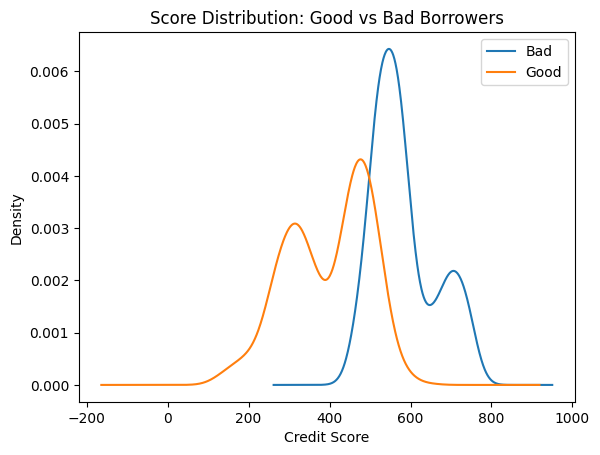

In [ ]:
# Score distribution for good vs bad
import matplotlib.pyplot as plt
train_score['loan_status'] = train['loan_status'].values
train_score.groupby('loan_status')['score'].plot(kind='kde')
plt.title('Score Distribution: Good vs Bad Borrowers')
plt.xlabel('Credit Score')
plt.legend(['Bad', 'Good'])
plt.show()

# Validate Scorecard and compare against XGBOOST

**Evaluate ScoreCard performance with industry metrics**

Before you can deploy a scorecard, you need to prove it discriminates between defaulters and non-defaulters. The KS statistic measures the maximum separation between the cumulative distributions of good and bad borrowers. The AUC measures overall ranking accuracy

In [ ]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt

xgboost provides the gradient boosting challenger model you will compare against your scorecard.



shap computes SHAP values to explain the XGBoost model's predictions.



matplotlib.pyplot handles plotting that sc.perf_eva() relies on for rendering KS and ROC curves.

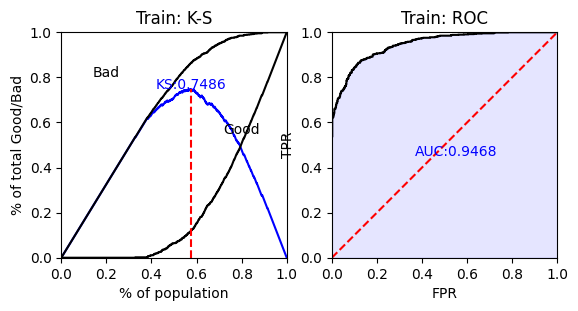

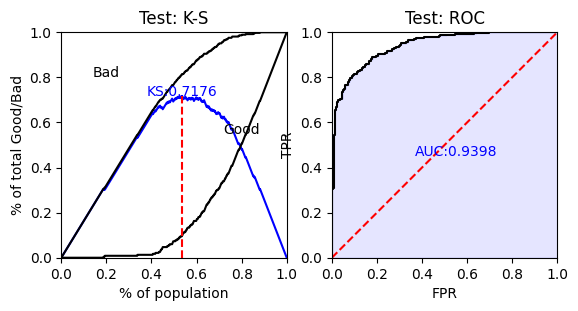

Train KS: 0.7486 Train AUC: 0.9468
Test KS: 0.7176 Test AUC: 0.9398


In [ ]:
# Evaluate scorecard performance
perf_train = sc.perf_eva(y_train, train_pred, title='Train')
perf_test = sc.perf_eva(y_test, test_pred, title='Test')
print('Train KS:', perf_train['KS'], 'Train AUC:', perf_train['AUC'])
print('Test KS:', perf_test['KS'], 'Test AUC:', perf_test['AUC'])

sc.perf_eva() takes the true labels and predicted probabilities, then computes KS, AUC, and Gini metrics. It also generates KS and ROC plots inline.

You evaluate both train and test sets so you can check for overfitting. If the train metrics are vastly higher than test, the model memorized the training data rather than learning generalizable patterns.

💡 How do I interpret these numbers?





KS above 40% is strong for application scorecards. 20-30% is acceptable.



AUC above 0.70 means the model ranks borrowers better than chance. Above 0.80 is strong.



A small gap between train and test metrics (less than 5-10 percentage points) confirms the model generalizes well.

🙋‍♀️ Not seeing plots or getting an error?





Make sure you have matplotlib imported. The perf_eva function relies on it for plot rendering.



Check that y_train and train_pred are defined in a cell that ran before this one. Your earlier cells must have executed successfully.



If the dictionary key lookup fails, print the returned object directly with print(perf_test) to see the available keys.

**Train XG Boost challenger model**

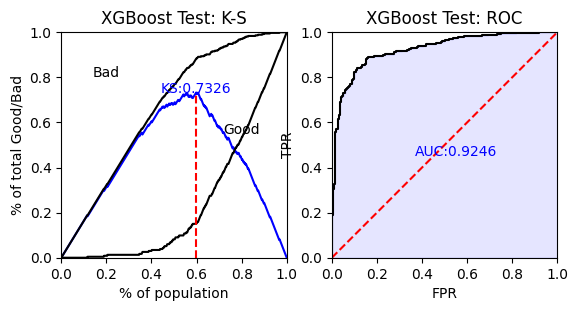

XGBoost Test KS: 0.7326 XGBoost Test AUC: 0.9246


In [ ]:
# Train XGBoost challenger
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
xgb_model = xgb.XGBClassifier(scale_pos_weight=neg/pos, random_state=42, eval_metric='auc')
xgb_model.fit(X_train, y_train)
xgb_test_pred = xgb_model.predict_proba(X_test)[:, 1]
xgb_perf = sc.perf_eva(y_test, xgb_test_pred, title='XGBoost Test')
print('XGBoost Test KS:', xgb_perf['KS'], 'XGBoost Test AUC:', xgb_perf['AUC'])

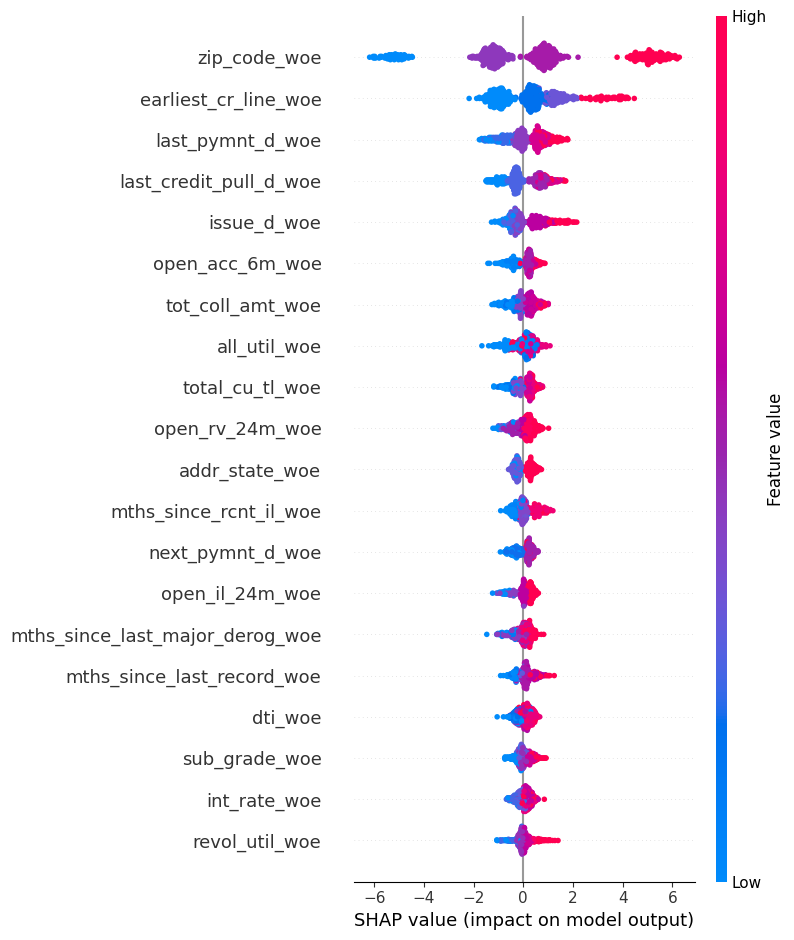

Scorecard AUC: 0.9398
XGBoost AUC: 0.9246
Rationale: Logistic Regression scorecard is preferred for regulatory transparency, auditability, and competitive performance on this dataset size.


In [ ]:
# SHAP explainability for XGBoost
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

# Decision rationale
print('Scorecard AUC:', perf_test['AUC'])
print('XGBoost AUC:', xgb_perf['AUC'])
print('Rationale: Logistic Regression scorecard is preferred for regulatory transparency, auditability, and competitive performance on this dataset size.')